# Generalization Experiments

Generalization Gap: difference between training and test accuracy 

In [2]:
# Cell 1: Imports and Data Loading
import pandas as pd
import matplotlib.pyplot as plt

import seaborn as sns
import json
import numpy as np

# Load the datasets
best_per_dataset = pd.read_csv('../processed_results/best_per_dataset.csv')
best_avg = pd.read_csv('../processed_results/best_avg.csv')
results_hp = pd.read_csv('../results_with_hyperparameters.csv')

# Set aesthetic style
sns.set_theme(style="whitegrid")
%matplotlib inline

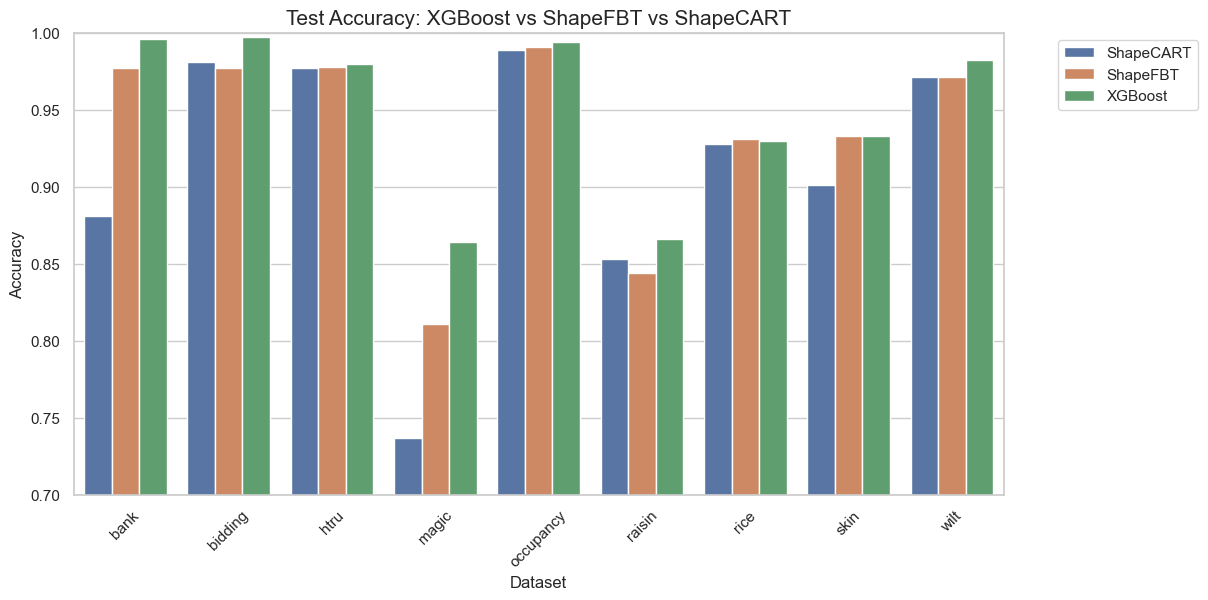

In [8]:
# Cell 2: Test Accuracy Comparison per Dataset
excluded_datasets = {'avila', 'bean', 'eye-state', 'fault', 'page', 'room', 'segment'}
filtered_best_per_dataset = best_per_dataset[
    ~best_per_dataset['dataset'].str.lower().isin(excluded_datasets)
]

plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_best_per_dataset, x='dataset', y='test_acc', hue='model')
plt.title('Test Accuracy: XGBoost vs ShapeFBT vs ShapeCART', fontsize=15)
plt.ylabel('Accuracy')
plt.xlabel('Dataset')
plt.ylim(0.7, 1.0) # Adjusted to zoom in on the differences
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

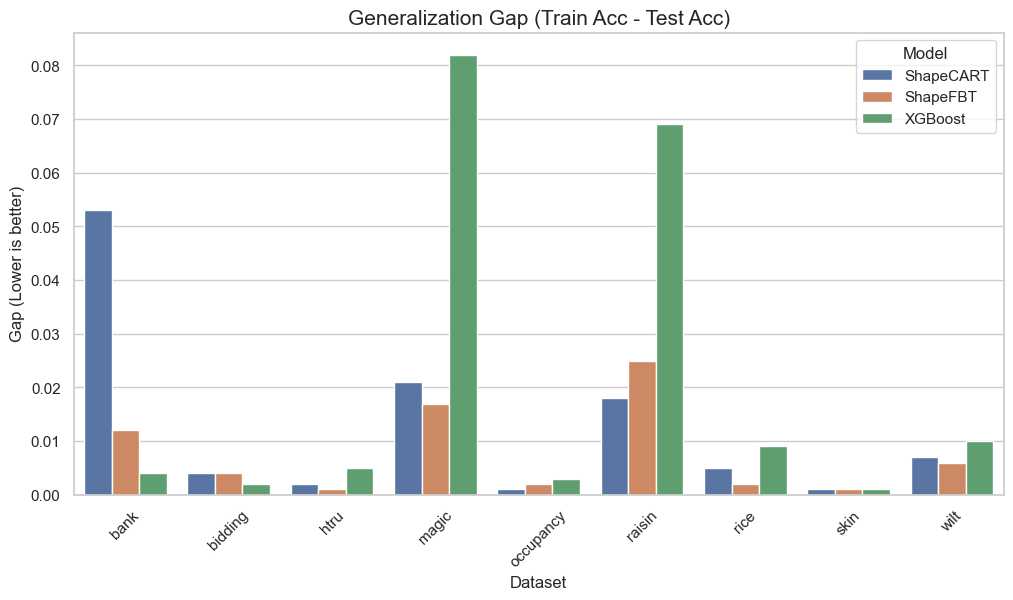

In [9]:
# Cell 3: Generalization Gap Analysis
# (Lower is better - indicates less overfitting)
plt.figure(figsize=(12, 6))
sns.barplot(data=filtered_best_per_dataset, x='dataset', y='generalization_gap', hue='model')
plt.title('Generalization Gap (Train Acc - Test Acc)', fontsize=15)
plt.ylabel('Gap (Lower is better)')
plt.xlabel('Dataset')
plt.legend(title='Model')
plt.xticks(rotation=45)
plt.show()

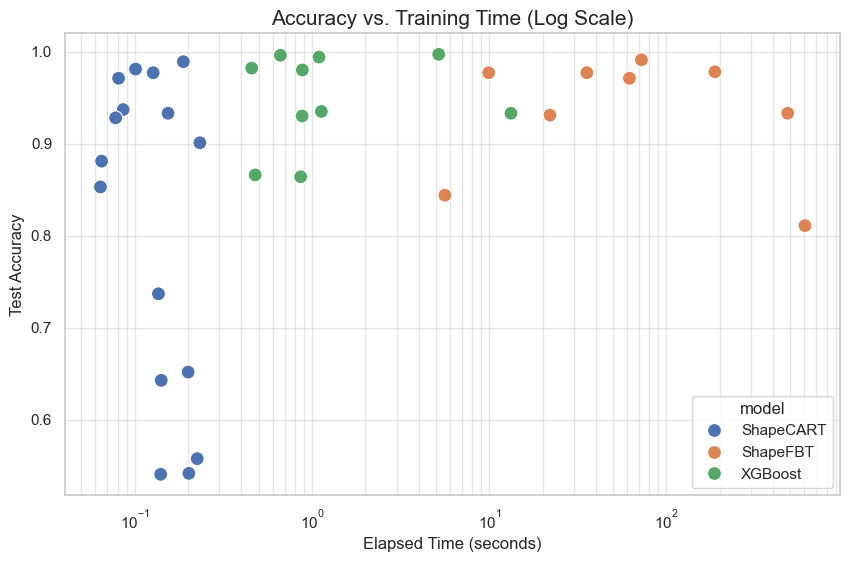

In [5]:
# Cell 4: Performance vs. Training Time (Log Scale)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=best_per_dataset, x='elapsed_time', y='test_acc', hue='model', s=100)
plt.xscale('log')
plt.title('Accuracy vs. Training Time (Log Scale)', fontsize=15)
plt.xlabel('Elapsed Time (seconds)')
plt.ylabel('Test Accuracy')
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.show()

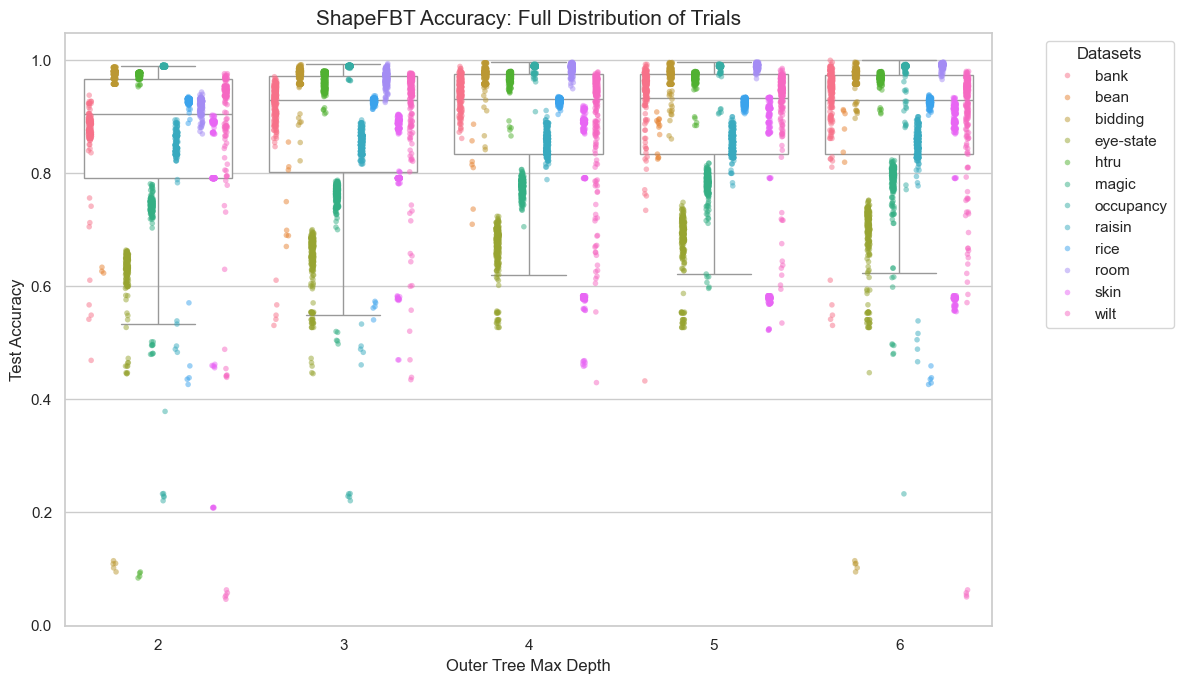

In [8]:
# Cell 5: Hyperparameter Analysis (All Points Visible)
plt.figure(figsize=(12, 7))

# 1. Draw the boxplot (the "summary")
# We set outlier_shape='' to hide the default outlier diamonds 
# so they don't double-count with our circles.
sns.boxplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc',
    color='white',
    showfliers=False
)

# 2. Draw the "circles" (the individual trials)
# Using 'hue' here will color the circles by dataset, 
# which explains why some are high and some are low.
sns.stripplot(
    data=shape_full.dropna(subset=['test_acc']), 
    x='outer_tree_max_depth', 
    y='test_acc', 
    hue='dataset',
    jitter=True, 
    alpha=0.5, 
    dodge=True,  # This aligns circles with the dataset legend
    size=4
)

plt.title('ShapeFBT Accuracy: Full Distribution of Trials', fontsize=15)
plt.xlabel('Outer Tree Max Depth')
plt.ylabel('Test Accuracy')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Datasets")
plt.tight_layout()
plt.show()

/var/folders/f2/g658svqn1s7ff_f07dxlbl480000gn/T/ipykernel_63757/3489260211.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')


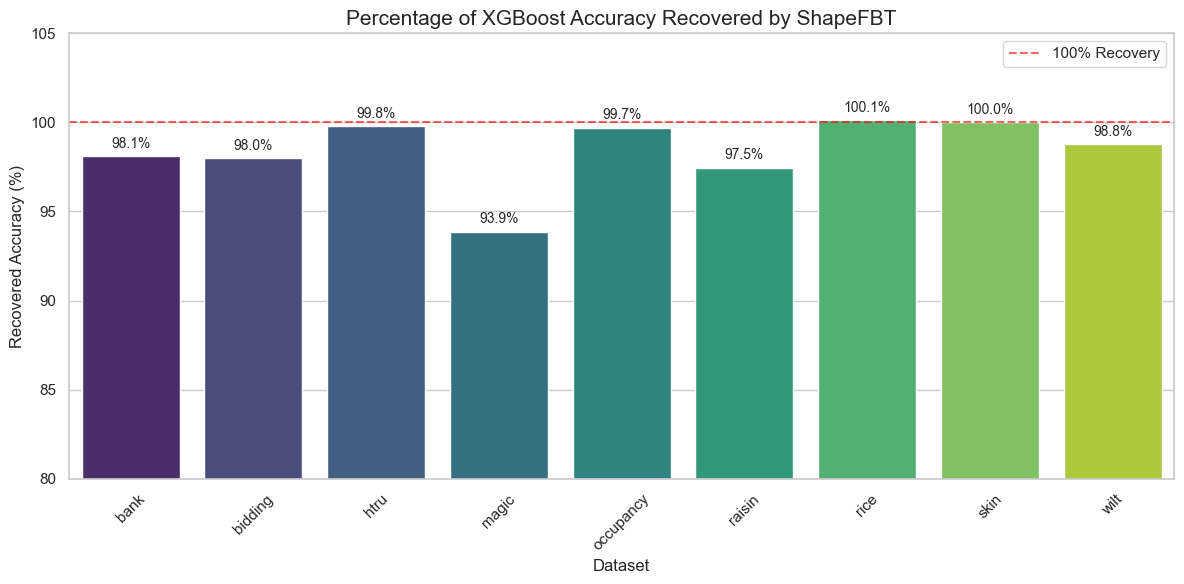

In [7]:
# Cell 6: Calculate and Plot Recovered Accuracy
# We define "Recovered Accuracy" as ShapeFBT_Test_Acc / XGBoost_Test_Acc

# 1. Prepare the data
xgb_best = best_per_dataset[best_per_dataset['model'] == 'XGBoost'][['dataset', 'test_acc']].rename(columns={'test_acc': 'xgb_acc'})
shape_best = best_per_dataset[best_per_dataset['model'] == 'ShapeFBT'][['dataset', 'test_acc']].rename(columns={'test_acc': 'shape_acc'})

# Merge and calculate ratio
recovered_df = pd.merge(xgb_best, shape_best, on='dataset').dropna()
recovered_df['recovered_accuracy'] = (recovered_df['shape_acc'] / recovered_df['xgb_acc']) * 100

# 2. Plotting
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=recovered_df, x='dataset', y='recovered_accuracy', palette='viridis')

# Add a reference line at 100% (Full Recovery)
plt.axhline(100, ls='--', color='red', alpha=0.6, label='100% Recovery')

# Annotate bars with the percentage value
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.title('Percentage of XGBoost Accuracy Recovered by ShapeFBT', fontsize=15)
plt.ylabel('Recovered Accuracy (%)')
plt.xlabel('Dataset')
plt.ylim(80, 105) # Focused on the 80-100% range
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()